**TARGET:**

- Want to get all the `image-caption` pairs from a pdf.

**ISSUE:**

- Used `Docling` for getting the same.
- Docling is not always able to detect correct pairs.
- For example I used a pdf `govt-food-data-report-large-table-heavy.pdf` (page no 480) with simple grid of 2 cols and 3 rows total 6 img-caption pairs. Docling is able to only the last row img-caption pairs, not the other pairs.
- I developed a wrapper module over docling which can detect all the pairs from a grid.
- But still this wrapper can not detect properly in some other condition. example pdf (`nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf`) page no 10.
- Need to solve this.

**TODO:**
1. Demonstrait docling failed page no 480 first ex pdf
2. Demonstrait wrapper successlully detected pairs in the previous example
3. Demonstrait wrapper failed page no 10 second ex pdf
4. Develop wrapper v2

## [ 1 ] Demonstrate: Bare Docling's Limitation in Img-Caption Pair Detection

In [1]:
from __future__ import annotations

import io
import fitz
from PIL import Image
from pathlib import Path
from pprint import pprint
from IPython.display import display

from statistics import median
from dataclasses import dataclass

from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

In [2]:
import json
from pathlib import Path
from docling.document_converter import DocumentConverter
from docling.datamodel.document import DoclingDocument
from docling_core.types.doc.document import PictureItem

In [3]:
def load_docling_document(pdf_path: str | Path) -> DoclingDocument:
    """
    Load a DoclingDocument from cache if available.
    Otherwise, convert the PDF and create the cache automatically.
    """

    pdf_path = Path(pdf_path)

    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    # Auto-generate cache path
    cache_path = pdf_path.with_suffix(".docling.json")

    # Load from cache
    if cache_path.exists():
        print(f"✅ Cache found. Loading cached document: {cache_path}")
        doc = DoclingDocument.load_from_json(cache_path)
        print(f"✅ Cache loaded as DoclingDocument")

    # Convert PDF and create cache
    else:
        print("⚠️ Cache not found.")
        print("⏳ Converting PDF using Docling DocumentConverter...")

        converter = DocumentConverter()
        result = converter.convert(pdf_path)
        doc = result.document

        # Save cache for future reuse
        doc.save_as_json(cache_path)

        print(f"✅ Conversion complete.")
        print(f"💾 Cache saved to: {cache_path}")

    # -----------------------------
    # Print document metadata
    # -----------------------------
    print("\n📄 Document Metadata")
    print("-" * 40)

    try:
        print(f"File Name      : {pdf_path.name}")
        print(f"Total Pages    : {len(doc.pages)}")
        print(f"Total Tables   : {len(doc.tables)}")
        print(f"Total Pictures : {len(doc.pictures)}")

        # Optional additional stats
        if hasattr(doc, "texts"):
            print(f"Text Blocks    : {len(doc.texts)}")

    except Exception as e:
        print(f"⚠️ Could not extract full metadata: {e}")

    print("-" * 40)

    return doc

In [4]:
# Example usage
pdf_path = (
    "/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/"
    "iid-platform/sample_data/named/"
    "govt-food-data-report-large-table-heavy.pdf"
)

doc = load_docling_document(pdf_path)

# Reuse `doc` multiple times below

✅ Cache found. Loading cached document: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/iid-platform/sample_data/named/govt-food-data-report-large-table-heavy.docling.json
✅ Cache loaded as DoclingDocument

📄 Document Metadata
----------------------------------------
File Name      : govt-food-data-report-large-table-heavy.pdf
Total Pages    : 585
Total Tables   : 474
Total Pictures : 455
Text Blocks    : 2748
----------------------------------------


**FUNCTIONS TO EXTRACT PICTURE-CAPTION PAIRS USING BARE DOCLING WAY**

In [5]:
def render_picture(
    picitem: PictureItem,
    pdf: fitz.Document,
    zoom: int = 2,
) -> fitz.Pixmap:
    """
    Render a cropped image from a PDF page using a Docling PictureItem.
    """

    # Convert 1-based page number -> 0-based
    page_no = picitem.prov[0].page_no - 1
    page = pdf[page_no]

    bbox = picitem.prov[0].bbox
    page_height = page.rect.height

    # Coordinate transform (BOTTOMLEFT -> TOPLEFT)
    x0 = bbox.l
    x1 = bbox.r
    y0 = page_height - bbox.t
    y1 = page_height - bbox.b

    rect = fitz.Rect(x0, y0, x1, y1)

    mat = fitz.Matrix(zoom, zoom)

    return page.get_pixmap(matrix=mat, clip=rect)


In [6]:
def get_caption(picitem: PictureItem, doc: DoclingDocument) -> str:
    """
    Extract caption text linked to a PictureItem.
    """

    texts = []

    for child in picitem.children:
        idx = int(child.cref.split("/")[-1])

        # Direct object access
        text_item = doc.texts[idx]

        if hasattr(text_item, "text"):
            texts.append(text_item.text)

    return " ".join(texts)


In [7]:
def display_page_pictures_with_captions(
    doc: DoclingDocument,
    pdf: fitz.Document,
    page_no: Optional[int] = None,
    picture_refs: Optional[Iterable[str]] = None,
    zoom: float = 2.0,
) -> None:
    """
    Display images from a Docling document along with captions.
    """

    for picitem in doc.pictures:

        if not isinstance(picitem, PictureItem):
            continue

        # --- Filtering ---
        match_page = (
            page_no is not None
            and picitem.prov
            and picitem.prov[0].page_no == page_no
        )

        match_ref = (
            picture_refs is not None
            and picitem.self_ref in picture_refs
        )

        if page_no is not None or picture_refs is not None:
            if not (match_page or match_ref):
                continue

        # --- Render image ---
        pix = render_picture(picitem, pdf, zoom=zoom)

        img = Image.open(io.BytesIO(pix.tobytes("png")))
        display(img)

        # --- Caption ---
        caption = get_caption(picitem, doc)

        print("Caption:", caption if caption else "[No caption]")
        print(f"Displayed: {picitem.self_ref}\n")


**EXAMPLE: Display Picture-Caption pairs from Page-480**

In [8]:
fitz_pdf = fitz.open(pdf_path)

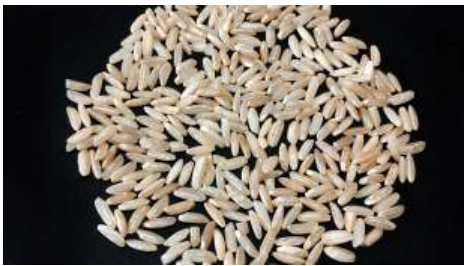

Caption: [No caption]
Displayed: #/pictures/36



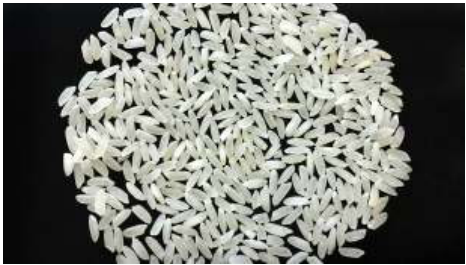

Caption: [No caption]
Displayed: #/pictures/37



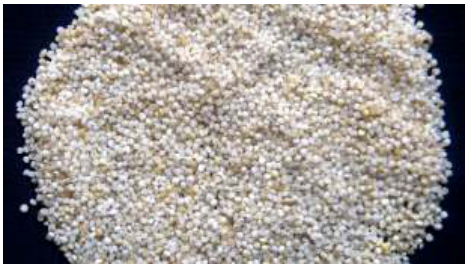

Caption: [No caption]
Displayed: #/pictures/38



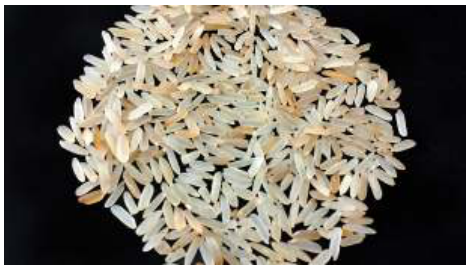

Caption: [No caption]
Displayed: #/pictures/39



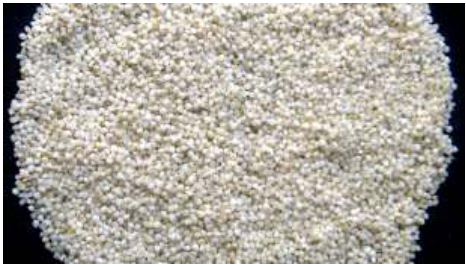

Caption: A016. Samai (Panicum miliare); B.  Sama;  G.  Kuri;  H. Shavan; Kan. Sama; Kash. Ganuhaar; Mal. Chama; Mar. Sava; O. Suan;  P. Swank; Tam. Samai; Tel. Sama.
Displayed: #/pictures/40



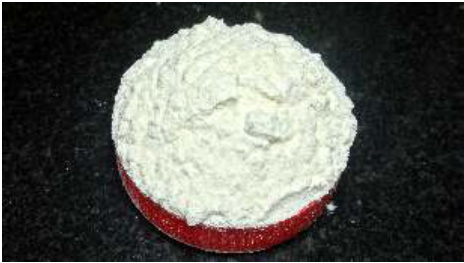

Caption: A018.  Wheat,  flour,  refined (Triticum  aestivum) ;  A. Moida; B. Maida; G. Maido;  H. Maida; Kan. Maida; Kash. Oat;  Kh.  Moida;  Mal.  Maida  mavu;  M.  Moida;  Mar. Maida; N. Maida; O. Maida; P. Maida;  Tam. Maida mavu; Tel. Maida pindi; U. Maida.
Displayed: #/pictures/41



In [9]:
# display_page_pictures_with_captions(docdict, fitz_pdf, picture_refs=[25])  # page_no=8)
# display_page_pictures_with_captions(docdict, fitz_pdf, page_no=480)
display_page_pictures_with_captions(doc, fitz_pdf, page_no=480)

**COMMENT/LIMITATION:** 
- Comparing with the actual PDF, it is clear that Docling is only able to detect last row image-picture pairs from a grid like structure. 

## [ 2 ] SUCCESS OF CUSTOM MADE WRAPPER MODULE

In [10]:
from functionalities.layout_geometry import *

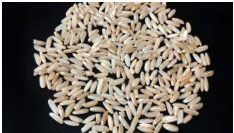

Figure Ref : #/pictures/36
Caption    : A013. Rice, raw, brown (Oryza sativa) ; A. Matia rangar chaul; G. Kathai chokha; H. Chawal; P. Bhura choul;  Kash. Tomul; Kh. Khaw saw; Mal. Kuthari ; M. Cheng; Tam. Arisi; Tel. Dampudu biyyam.



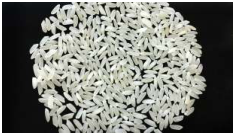

Figure Ref : #/pictures/37
Caption    : A015. Rice, raw, milled ( Oryza sativa ); A. Milat khunda chaul; B. Chowl; G. Choka; H. Chawal; Kan. Akki; Kash. Tomul;  Kh. Khaw boil; M. Cheng; Mar. Tondool; O. Chaula; P. Chaul;  Tam.   Arisi; Tel. Biyyam.



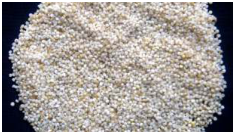

Figure Ref : #/pictures/38
Caption    : A017. Varagu ( Paspalum scrobiculatum );  A. Konidhan; B. Kodoadhan; G. Kodra; H. Koden; Kan. Harka; Kash. Snol; Mal. Koovaragu;  Mar. Karik; O. Kodus;  P. Kodra; Tam. Varagu; Tel.  Arikelu.



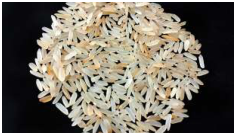

Figure Ref : #/pictures/39
Caption    : A014. Rice, parboiled, milled (Oryza sativa) ; A. Ukhua chaul;  B.  Siddha  chowl;  G.  Bafela  Chokha;  H.  Usna chawal; Kan. Kusubalakki; Kash. Tomul; Kh. Khaw boil; Mal. Puzhungal ari; M. Cheng; Mar. Ukadla tandool; O. Usuna chaula; P. Biga hua chawal;  Tam. Puzhungal arisi; Tel. Uppudu biyyam.



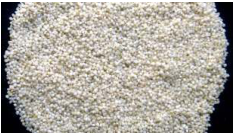

Figure Ref : #/pictures/40
Caption    : A016. Samai (Panicum miliare); B.  Sama;  G.  Kuri;  H. Shavan; Kan. Sama; Kash. Ganuhaar; Mal. Chama; Mar. Sava; O. Suan;  P. Swank; Tam. Samai; Tel. Sama.



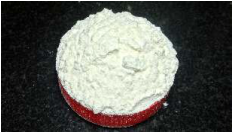

Figure Ref : #/pictures/41
Caption    : A018.  Wheat,  flour,  refined (Triticum  aestivum) ;  A. Moida; B. Maida; G. Maido;  H. Maida; Kan. Maida; Kash. Oat;  Kh.  Moida;  Mal.  Maida  mavu;  M.  Moida;  Mar. Maida; N. Maida; O. Maida; P. Maida;  Tam. Maida mavu; Tel. Maida pindi; U. Maida.

Processed 6 figure(s) from page 480.


In [12]:
export_page_figures(
    doc,
    fitz_pdf,
    page_no=480,
    zoom=1,
    mode="display",
)

**COMMENT/SUCCESS OF CUSTOM WRAPER:** 
- Comparing with the actual PDF, it is clear that Docling, with the custom made wrapper around, is able to detect all the image-caption pairs from grid correctly. This is a powerful wrapper. 

## [ 3 ] FAILURE OF CUSTOM MADE WRAPPER MODULE IN SOME SPECIFIC CASES

In [13]:
# Example usage
pdf_path = (
    "/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/"
    "iid-platform/sample_data/named/"
    # "govt-food-data-report-large-table-heavy.pdf"
    "nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf"
)

doc = load_docling_document(pdf_path)
fitz_pdf = fitz.open(pdf_path)
# Reuse `doc` multiple times below

⚠️ Cache not found.
⏳ Converting PDF using Docling DocumentConverter...


[INFO] 2026-05-22 16:21:00,517 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-22 16:21:00,868 [RapidOCR] download_file.py:60: File exists and is valid: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-05-22 16:21:00,869 [RapidOCR] main.py:53: Using /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-05-22 16:21:01,088 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-22 16:21:01,161 [RapidOCR] download_file.py:60: File exists and is valid: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-05-22 16:21:01,162 [RapidOCR] main.py:53: Using /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer

✅ Conversion complete.
💾 Cache saved to: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/iid-platform/sample_data/named/nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.docling.json

📄 Document Metadata
----------------------------------------
File Name      : nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf
Total Pages    : 40
Total Tables   : 0
Total Pictures : 82
Text Blocks    : 744
----------------------------------------


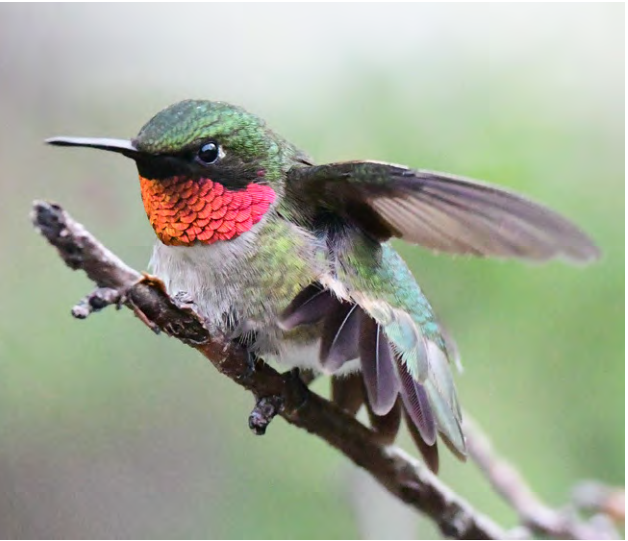

Figure Ref : #/pictures/20
Caption    : Hummingbirds often urinate while hovering, as this juvenile male rufous demonstrates.  MYRNA PEARMAN



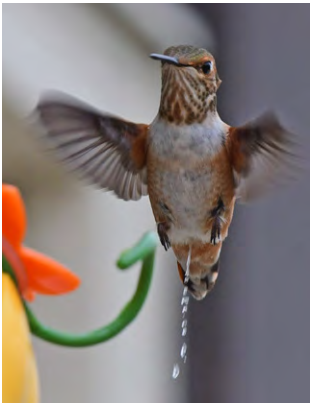

Figure Ref : #/pictures/21
Caption    : [No caption found]



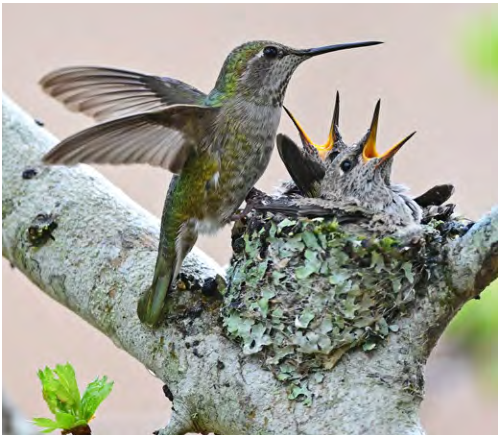

Figure Ref : #/pictures/22
Caption    : Left: An adult male ruby-throated hummingbird at rest, enjoying a good stretch and flaunting his bright gorget. MYRNA PEARMAN Above: Female hummingbirds, like this adult Anna's hummingbird, work tirelessly to feed their hungry nestlings. MYRNA PEARMAN

Processed 3 figure(s) from page 10.


In [14]:
export_page_figures(
    doc,
    fitz_pdf,
    page_no=10,
    zoom=2,
    mode="display",
)

**COMMENT/SUCCESS OF CUSTOM WRAPER:**

- Comparing with the actual PDF, it is clear that Docling, with the custom made wrapper around, failed here. This is not a grid.
- It also mismatched img-cap pairs, first image had no caption, second img had the cap and it assigned it to first image, and left second image with no caption.
- Also it doesn't have any natural language ability and map accordingly, so, in third image caption came so. 